# v4 35k baseline 모델

Goal:

- Keep a fixed BSD10k split: train 80% / final test 20%.
- Use the same `dcase2026_task1_baseline` `BaseClassifier` and metrics.
- Add BSD35k v4-filtered data and evaluate on the untouched BSD10k final test set.

Datasets compared:

- `v4_all`: BSD10k train80 + all usable BSD35k rows from the v4 prediction file.
- `v4_ge2`, `v4_ge3`, `v4_ge4`: BSD10k train80 + BSD35k filtered by v4 pseudo confidence.


Important: v4 score is not a direct 1-5 classifier. This notebook follows the existing convention:

```text
predicted_confidence_score = 1 + 4 * v4_filter_score
ge2 = predicted_confidence_score >= 2
ge3 = predicted_confidence_score >= 3
ge4 = predicted_confidence_score >= 4
```

In [22]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import StratifiedKFold

HERE = Path.cwd()
if not (HERE / 'baseline_confidnce_train').exists():
    # Allows running this notebook from the notebooks/ directory.
    ROOT = HERE.parent
else:
    ROOT = HERE

sys.path.insert(0, str(ROOT / 'baseline_confidnce_train'))
sys.path.insert(0, str(ROOT / 'dcase2026_task1_baseline'))

import confidence_baseline_common as cbc

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64
OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_35k_baseline_model'
PLOTS_DIR = OUTPUT_ROOT / 'plots'
DATASET_DIR = OUTPUT_ROOT / 'datasets'
for path in [OUTPUT_ROOT, PLOTS_DIR, DATASET_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
cbc.seed_everything(SEED)

print('ROOT:', ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('device:', cbc.device_summary())

ROOT: c:\Users\solok\Desktop\Dcase baseline
OUTPUT_ROOT: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model
device: cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)


## 1. Fixed BSD10k 80/20 split

`final_test` is held out before any BSD35k addition and is used only for final evaluation.

In [23]:
full_df, class_dict, top_class_dict = cbc.load_baseline_assets(ROOT)
train_pool, final_test, split_df = cbc.make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED, test_size=0.2)

print('BSD10k full:', len(full_df))
print('BSD10k train_pool 80%:', len(train_pool))
print('BSD10k final_test 20%:', len(final_test))
print('classes in train_pool:', train_pool['class'].nunique())
print('classes in final_test:', final_test['class'].nunique())
display(split_df.head())

BSD10k full: 10956
BSD10k train_pool 80%: 8764
BSD10k final_test 20%: 2192
classes in train_pool: 23
classes in final_test: 23


,sound_id,class,class_idx,split
0,148475,is-k,6,train_pool
1,246968,is-w,5,train_pool
2,247907,is-s,4,train_pool
3,93909,is-p,3,train_pool
4,78499,ss-u,21,train_pool


## 2. Load BSD35k v4 predictions and build DCASE-compatible rows

The existing v4 file already contains v2/v3-derived scores for BSD35k:

- `binary_mlp_prob` from v3 binary confidence model
- `fiveclass_score`, `fiveclass_p45` from v2 5-class model
- `v4_filter_score` from v4 rank-average ensemble

In [24]:
BSD35K_V4_PATH = ROOT / 'outputs' / 'confidence_filter_v4' / 'predictions' / 'BSD35k-CS_filter_predictions_v4.csv'
assert BSD35K_V4_PATH.exists(), f'Missing file: {BSD35K_V4_PATH}'

def build_bsd35k_dcase_dataframe(v4_path: Path) -> pd.DataFrame:
    score_df = pd.read_csv(v4_path)
    score_df['sound_id'] = score_df['sound_id'].astype(str)
    top_col = 'class_top' if 'class_top' in score_df.columns else 'top_class'
    needed = ['sound_id', 'class', top_col, 'v4_filter_score', 'binary_mlp_prob', 'fiveclass_score', 'fiveclass_p45']
    missing = [col for col in needed if col not in score_df.columns]
    if missing:
        raise ValueError(f'Missing columns in BSD35k v4 file: {missing}')

    # Do NOT reuse score_df['class_idx']: in the BSD35k v4 file it is not the
    # DCASE baseline 0-22 class index. Re-map from class/top_class using
    # data/class_dict.json and data/top_class_dict.json.
    out = score_df[needed].copy().rename(columns={top_col: 'top_class'})
    out['index'] = out['sound_id'].astype(str)
    out['class'] = out['class'].astype(str)
    out['top_class'] = out['top_class'].astype(str)
    out['class_idx'] = out['class'].map(class_dict)
    out['top_class_idx'] = out['top_class'].map(top_class_dict)

    # BSD10k and BSD35k embeddings are stored in different folders.
    bsd35k_audio_dir = ROOT / 'data' / 'features' / 'BSD35k_clap_audio_embeddings'
    bsd35k_text_dir = ROOT / 'data' / 'features' / 'BSD35k-CS_clap_text_embeddings'
    if not bsd35k_audio_dir.exists():
        raise FileNotFoundError(f'Missing BSD35k audio embedding folder: {bsd35k_audio_dir}')
    if not bsd35k_text_dir.exists():
        raise FileNotFoundError(f'Missing BSD35k text embedding folder: {bsd35k_text_dir}')
    out['audio_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_audio_dir / f'{sid}.npy'))
    out['text_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_text_dir / f'{sid}.npy'))
    out['predicted_confidence_score'] = 1.0 + 4.0 * out['v4_filter_score'].astype(float)

    before = len(out)
    bsd10k_ids = set(full_df['index'].astype(str))
    out = out[~out['index'].isin(bsd10k_ids)].copy()

    unknown_class = out['class_idx'].isna().sum()
    unknown_top = out['top_class_idx'].isna().sum()
    missing_audio = (~out['audio_emb_filepath'].map(lambda p: Path(p).exists())).sum()
    missing_text = (~out['text_emb_filepath'].map(lambda p: Path(p).exists())).sum()
    print(f'Unknown DCASE class rows: {unknown_class:,}')
    print(f'Unknown DCASE top-class rows: {unknown_top:,}')
    print(f'Missing BSD35k audio embeddings: {missing_audio:,}')
    print(f'Missing BSD35k text embeddings: {missing_text:,}')

    out = out[out['class_idx'].notna() & out['top_class_idx'].notna()].copy()
    out = out[out['audio_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out = out[out['text_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out['class_idx'] = out['class_idx'].astype(int)
    out['top_class_idx'] = out['top_class_idx'].astype(int)
    out = out.reset_index(drop=True)
    print(f'BSD35k rows before compatibility filtering: {before:,}')
    print(f'BSD35k rows usable by DCASE baseline: {len(out):,}')
    print(f'BSD35k classes retained: {out["class"].nunique()}')
    return out

bsd35k_all = build_bsd35k_dcase_dataframe(BSD35K_V4_PATH)
bsd35k_all.to_csv(DATASET_DIR / 'bsd35k_all_usable.csv', index=False)
display(bsd35k_all.head())

Unknown DCASE class rows: 0
Unknown DCASE top-class rows: 0
Missing BSD35k audio embeddings: 0
Missing BSD35k text embeddings: 0
BSD35k rows before compatibility filtering: 31,464
BSD35k rows usable by DCASE baseline: 31,464
BSD35k classes retained: 23


,sound_id,class,top_class,v4_filter_score,binary_mlp_prob,fiveclass_score,fiveclass_p45,index,class_idx,top_class_idx,audio_emb_filepath,text_emb_filepath,predicted_confidence_score
0,796088,fx-h,fx,0.851735,0.745651,3.783054,0.784744,796088,14,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,4.406941
1,796133,fx-n,fx,0.384630,0.501452,3.406448,0.441924,796133,16,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.538520
2,796149,ss-n,ss,0.327088,0.471124,3.375044,0.448676,796149,19,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.308352
3,796181,ss-n,ss,0.661121,0.588156,3.671201,0.702746,796181,19,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,3.644483
4,796221,is-e,is,0.069842,0.357983,2.913855,0.241068,796221,7,1,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,1.279367


## 3. Build v4 ge2/ge3/ge4 subsets and visualize counts

Each subset is created from BSD35k only. The BSD10k train80 anchor is added later during downstream training.

,subset,threshold,samples,ratio_of_usable_bsd35k,num_classes
0,ge2,2.0,23851,0.758041,23
1,ge3,3.0,15566,0.494724,23
2,ge4,4.0,7633,0.242595,23


,dataset_label,bsd10k_train80_samples,added_bsd35k_samples,total_train_samples,bsd10k_train80_classes,added_bsd35k_classes,total_classes
0,v4_all,8764,31464,40228,23,23,23
1,v4_ge2,8764,23851,32615,23,23,23
2,v4_ge3,8764,15566,24330,23,23,23
3,v4_ge4,8764,7633,16397,23,23,23


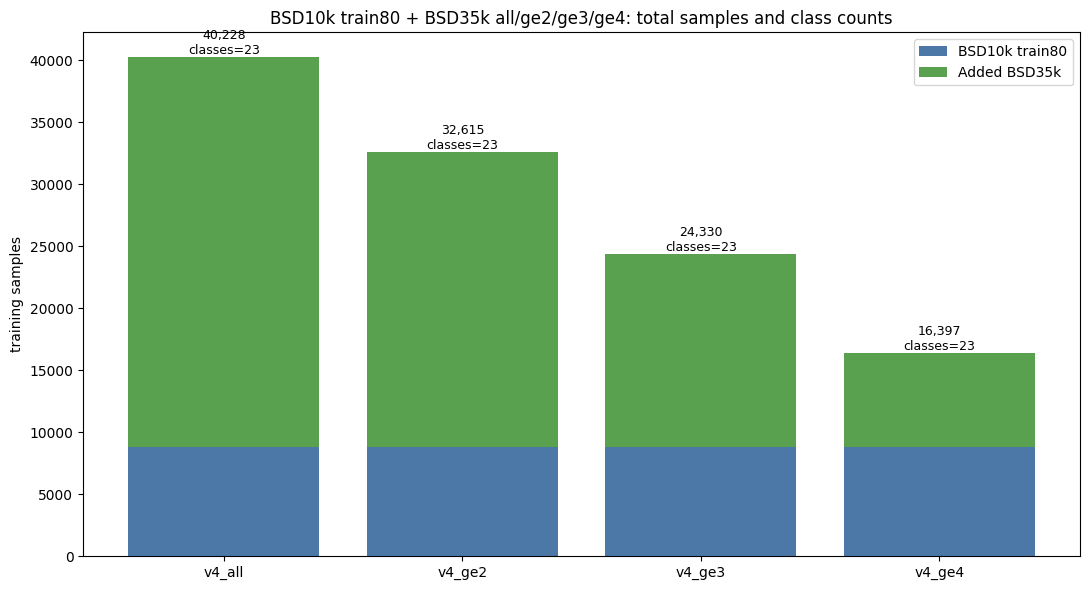

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\bsd10k_train80_plus_bsd35k_combined_counts.png


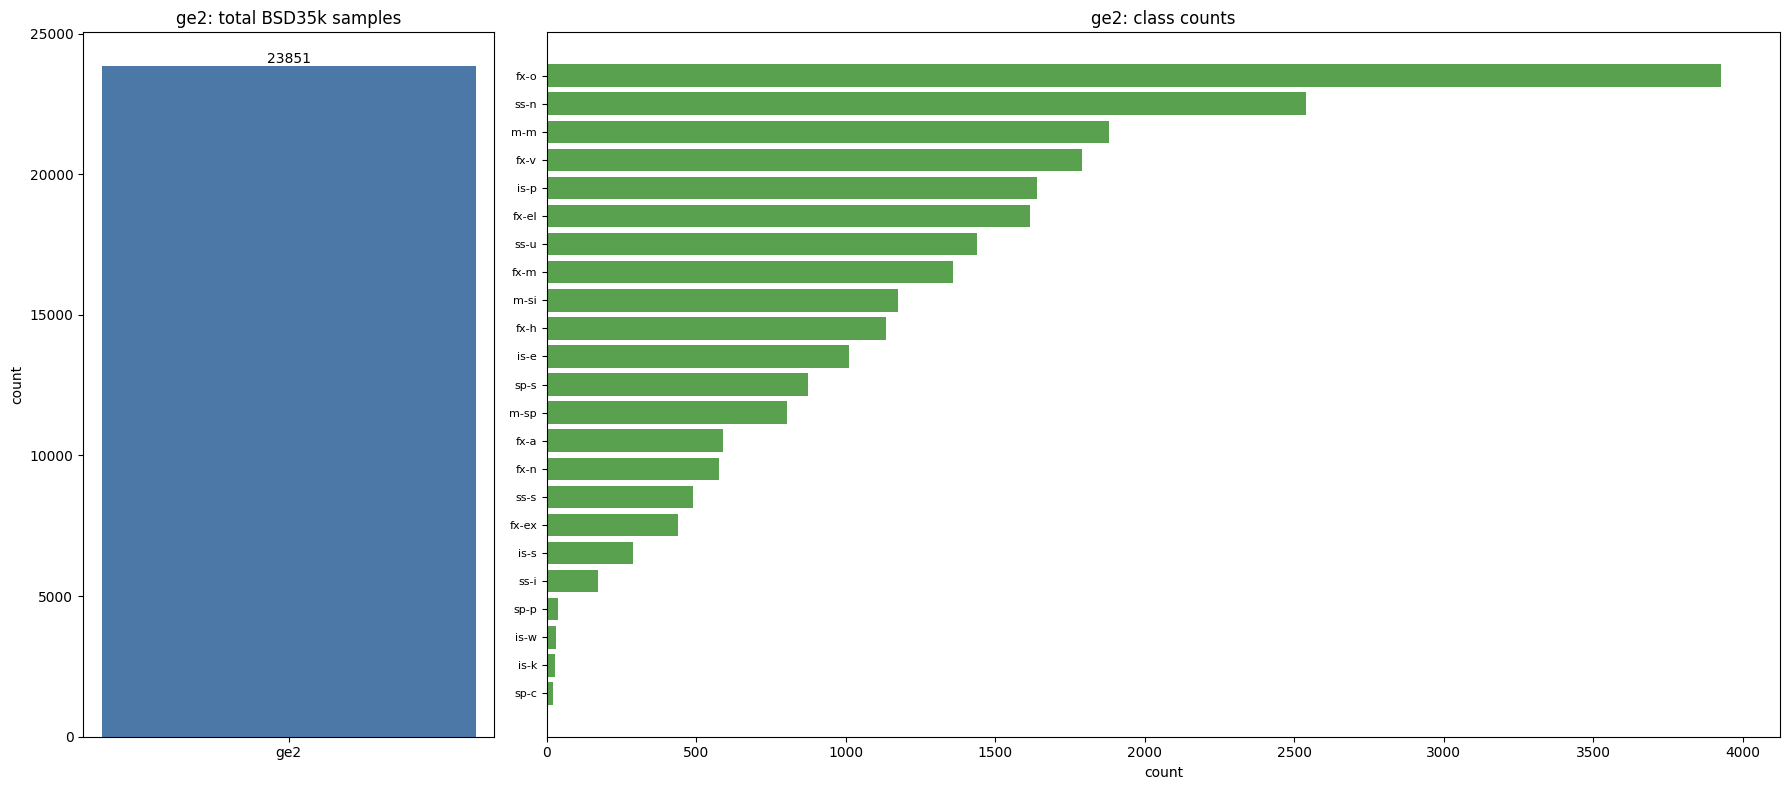

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\bsd35k_ge2_counts.png


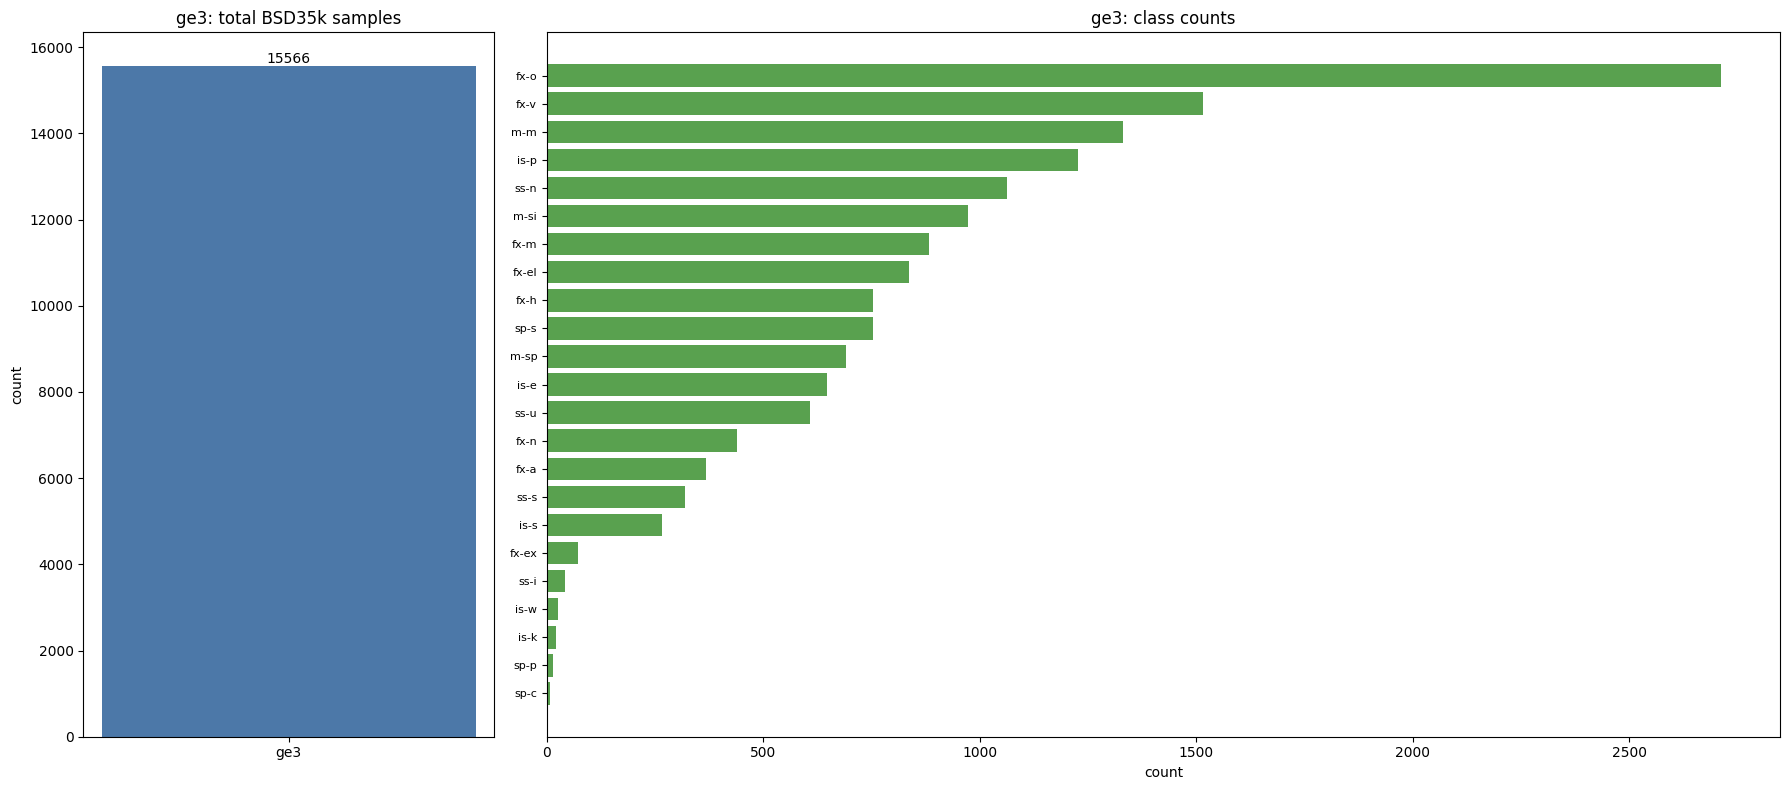

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\bsd35k_ge3_counts.png


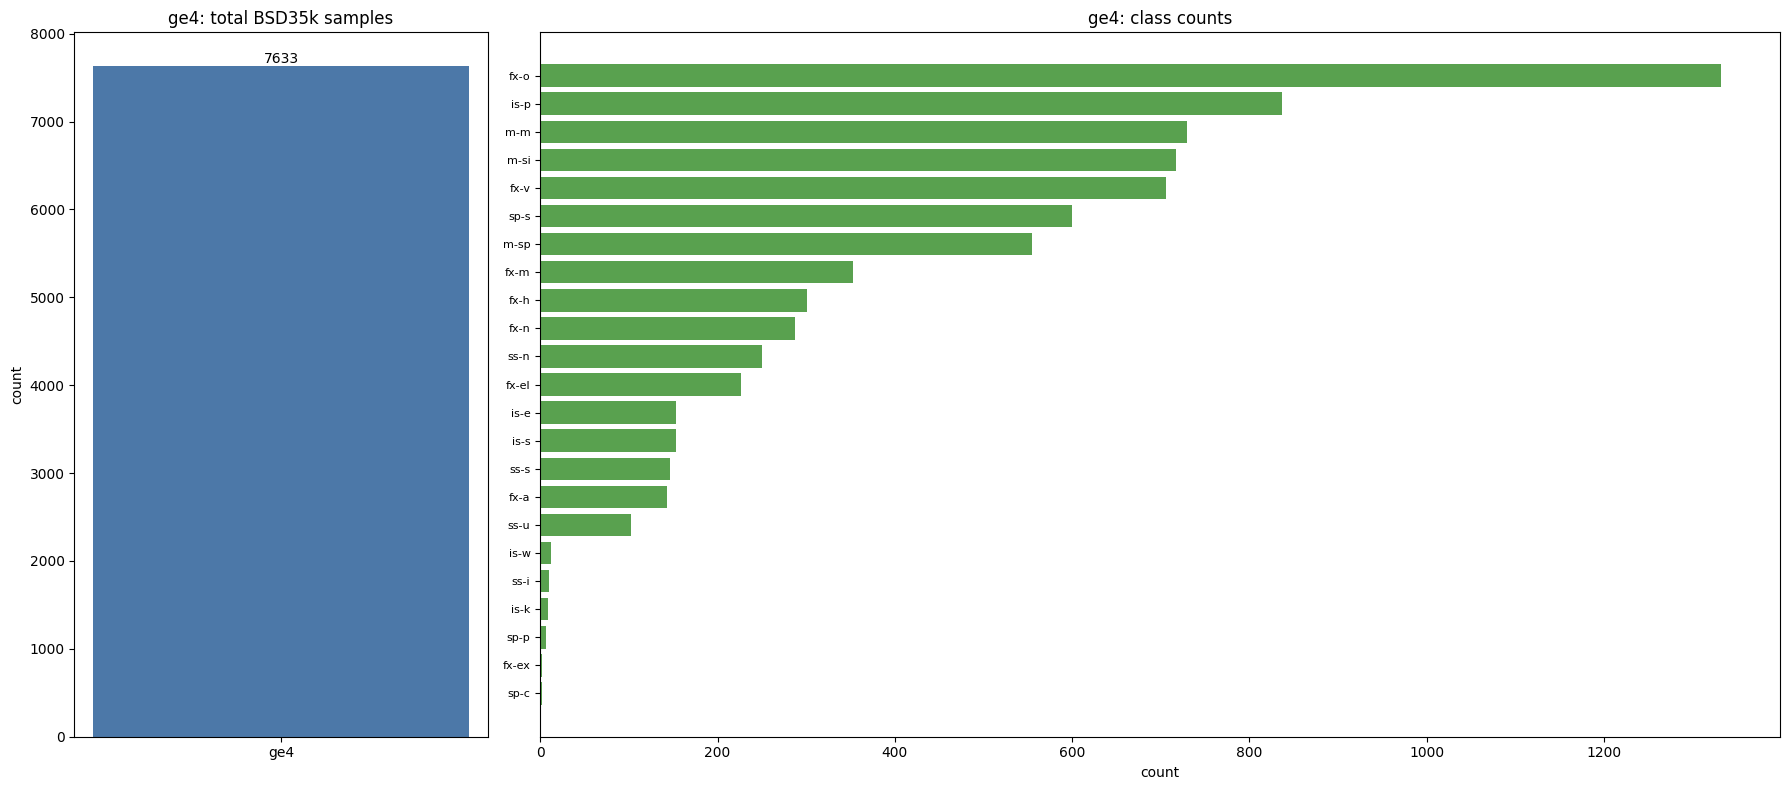

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\bsd35k_ge4_counts.png


In [25]:
THRESHOLD_SPECS = [
    {'label': 'ge2', 'threshold': 2.0},
    {'label': 'ge3', 'threshold': 3.0},
    {'label': 'ge4', 'threshold': 4.0},
]

v4_subsets = {}
for spec in THRESHOLD_SPECS:
    label = spec['label']
    threshold = spec['threshold']
    subset = bsd35k_all[bsd35k_all['predicted_confidence_score'] >= threshold].reset_index(drop=True)
    v4_subsets[label] = subset
    subset.to_csv(DATASET_DIR / f'bsd35k_v4_{label}.csv', index=False)

counts_rows = []
for label, subset in v4_subsets.items():
    counts_rows.append({
        'subset': label,
        'threshold': next(s['threshold'] for s in THRESHOLD_SPECS if s['label'] == label),
        'samples': len(subset),
        'ratio_of_usable_bsd35k': len(subset) / len(bsd35k_all),
        'num_classes': subset['class'].nunique(),
    })

subset_counts = pd.DataFrame(counts_rows)
subset_counts.to_csv(OUTPUT_ROOT / 'v4_bsd35k_subset_counts.csv', index=False)
display(subset_counts)

combined_count_sets = {'v4_all': bsd35k_all, **{f'v4_{label}': subset for label, subset in v4_subsets.items()}}
combined_count_rows = []
for dataset_label, add_df in combined_count_sets.items():
    combined = pd.concat([train_pool, add_df[train_pool.columns]], ignore_index=True)
    combined_count_rows.append({
        'dataset_label': dataset_label,
        'bsd10k_train80_samples': len(train_pool),
        'added_bsd35k_samples': len(add_df),
        'total_train_samples': len(combined),
        'bsd10k_train80_classes': train_pool['class'].nunique(),
        'added_bsd35k_classes': add_df['class'].nunique() if len(add_df) else 0,
        'total_classes': combined['class'].nunique(),
    })

combined_counts = pd.DataFrame(combined_count_rows)
combined_counts.to_csv(OUTPUT_ROOT / 'bsd10k_train80_plus_bsd35k_combined_counts.csv', index=False)
display(combined_counts)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(combined_counts))
ax.bar(x, combined_counts['bsd10k_train80_samples'], label='BSD10k train80', color='#4C78A8')
ax.bar(
    x,
    combined_counts['added_bsd35k_samples'],
    bottom=combined_counts['bsd10k_train80_samples'],
    label='Added BSD35k',
    color='#59A14F',
)
ax.set_xticks(x)
ax.set_xticklabels(combined_counts['dataset_label'], rotation=0)
ax.set_ylabel('training samples')
ax.set_title('BSD10k train80 + BSD35k all/ge2/ge3/ge4: total samples and class counts')
ax.legend(loc='upper right')
for i, row in combined_counts.iterrows():
    ax.text(
        i,
        row['total_train_samples'],
        f"{int(row['total_train_samples']):,}\nclasses={int(row['total_classes'])}",
        ha='center',
        va='bottom',
        fontsize=9,
    )
fig.tight_layout()
combined_counts_plot = PLOTS_DIR / 'bsd10k_train80_plus_bsd35k_combined_counts.png'
fig.savefig(combined_counts_plot, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', combined_counts_plot)

def plot_subset_total_and_class_counts(label: str, subset: pd.DataFrame):
    class_counts = subset['class'].value_counts().sort_values(ascending=True)
    class_counts.to_csv(OUTPUT_ROOT / f'class_counts_{label}.csv', header=['count'])

    fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 3]})
    axes[0].bar([label], [len(subset)], color='#4C78A8')
    axes[0].set_title(f'{label}: total BSD35k samples')
    axes[0].set_ylabel('count')
    axes[0].bar_label(axes[0].containers[0], fmt='%d')

    axes[1].barh(class_counts.index.astype(str), class_counts.values, color='#59A14F')
    axes[1].set_title(f'{label}: class counts')
    axes[1].set_xlabel('count')
    axes[1].tick_params(axis='y', labelsize=8)
    fig.tight_layout()
    save_path = PLOTS_DIR / f'bsd35k_{label}_counts.png'
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', save_path)

for label, subset in v4_subsets.items():
    plot_subset_total_and_class_counts(label, subset)

## 4. Build downstream datasets

This version includes the requested unfiltered BSD35k-all addition plus the three v4-filtered BSD35k additions.

In [26]:
addition_sets = {
    'v4_all': bsd35k_all,
    'v4_ge2': v4_subsets['ge2'],
    'v4_ge3': v4_subsets['ge3'],
    'v4_ge4': v4_subsets['ge4'],
}

dataset_rows = []
for label, add_df in addition_sets.items():
    combined = pd.concat([train_pool, add_df[train_pool.columns]], ignore_index=True)
    dataset_path = DATASET_DIR / f'{label}_train_dataset.csv'
    combined.to_csv(dataset_path, index=False)
    add_df.to_csv(DATASET_DIR / f'{label}_added_bsd35k_rows.csv', index=False)
    dataset_rows.append({
        'dataset_label': label,
        'bsd10k_train80_samples': len(train_pool),
        'added_bsd35k_samples': len(add_df),
        'total_train_pool_samples': len(combined),
        'added_bsd35k_classes': add_df['class'].nunique() if len(add_df) else 0,
        'total_classes': combined['class'].nunique(),
        'dataset_csv': str(dataset_path),
    })

dataset_manifest = pd.DataFrame(dataset_rows)
dataset_manifest.to_csv(OUTPUT_ROOT / 'dataset_manifest.csv', index=False)
display(dataset_manifest)

,dataset_label,bsd10k_train80_samples,added_bsd35k_samples,total_train_pool_samples,added_bsd35k_classes,total_classes,dataset_csv
0,v4_all,8764,31464,40228,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_ge2,8764,23851,32615,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_ge3,8764,15566,24330,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_ge4,8764,7633,16397,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...


## 5. Train DCASE baseline on each dataset

This uses the same model and evaluation code from `dcase2026_task1_baseline` via `confidence_baseline_common.train_and_evaluate_one`.

To reduce runtime while debugging, edit `RUN_DATASET_LABELS` before executing the cell.

In [27]:
RUN_DATASET_LABELS = [
    'v4_all',
    'v4_ge2',
    'v4_ge3',
    'v4_ge4',
]

def make_combined_dataset(addition_df: pd.DataFrame) -> pd.DataFrame:
    if len(addition_df) == 0:
        return train_pool.reset_index(drop=True).copy()
    return pd.concat([train_pool, addition_df[train_pool.columns]], ignore_index=True).reset_index(drop=True)

def run_one_dataset(dataset_label: str, combined_df: pd.DataFrame) -> list[dict]:
    rows = []
    dataset_dir = OUTPUT_ROOT / dataset_label
    dataset_dir.mkdir(parents=True, exist_ok=True)
    combined_df.to_csv(dataset_dir / 'combined_train_pool.csv', index=False)

    splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    splits = list(splitter.split(np.zeros(len(combined_df)), combined_df['class_idx']))

    for mode in BASELINE_MODES:
        for fold, (train_idx, val_idx) in enumerate(splits):
            split_name = f'fold_{fold}'
            run_dir = dataset_dir / mode / split_name
            tr_df = combined_df.iloc[train_idx].reset_index(drop=True)
            va_df = combined_df.iloc[val_idx].reset_index(drop=True)

            base_row = {
                'dataset_label': dataset_label,
                'mode': mode,
                'split': split_name,
                'train_pool_samples_before_kfold': int(len(combined_df)),
                'train_samples': int(len(tr_df)),
                'val_samples': int(len(va_df)),
                'final_test_samples': int(len(final_test)),
                'bsd10k_train80_samples': int(len(train_pool)),
                'added_bsd35k_samples': int(max(len(combined_df) - len(train_pool), 0)),
                'output_dir': str(run_dir),
            }

            metrics_path = run_dir / 'evaluation' / 'results.txt'
            if metrics_path.exists():
                metrics = cbc.read_metrics_file(metrics_path)
                rows.append({**base_row, 'status': 'completed_existing', **metrics})
                print('[skip] existing completed run:', run_dir)
                continue

            best_val_acc, metrics = cbc.train_and_evaluate_one(
                tr_df,
                va_df,
                final_test,
                class_dict,
                top_class_dict,
                run_dir,
                mode=mode,
                seed=SEED,
                batch_size=BATCH_SIZE,
                num_epochs=NUM_EPOCHS,
                lr=0.001,
                patience=5,
                early_stopping_factor=3,
            )
            rows.append({**base_row, 'status': 'ok', 'best_val_accuracy': float(best_val_acc), **metrics})
            pd.DataFrame(rows).to_csv(dataset_dir / 'summary_results_partial.csv', index=False)
    return rows

all_rows = []
for dataset_label in RUN_DATASET_LABELS:
    print('\n' + '=' * 100)
    print('Running dataset:', dataset_label)
    combined_df = make_combined_dataset(addition_sets[dataset_label])
    rows = run_one_dataset(dataset_label, combined_df)
    all_rows.extend(rows)
    pd.DataFrame(all_rows).to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)

summary = pd.DataFrame(all_rows)
summary.to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)
display(summary)


Running dataset: v4_all

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\v4_all\both\fold_0
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=32182, val=8046, final_test=2192
  batches: train=502, val=126, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 68.80%
  New best model saved
Epoch [2/100] - Val acc: 74.93%
  New best model saved
Epoch [3/100] - Val acc: 77.11%
  New best model saved
Epoch [4/100] - Val acc: 77.90%
  New best model saved
Epoch [5/100] - Val acc: 78.60%
  New best model saved
Epoch [6/100] - Val acc: 79.36%
  New best model saved
Epoch [7/100] - Val acc: 79.54%
  New best model saved
Epoch [8/100] - Val acc: 79.37%
Epoch [9/100] - Val acc: 80.51%
  New best model saved
Epoch [10/100] - Val acc: 79.89%
Epoch [11/100] - Val acc: 80.61%
  New best model saved
Epoch [12/100] - Val acc: 81.57%
  New best model saved
Epoch [13/100] - Val acc: 81.34%
Epoch [14/100] - Val acc: 81.52%
Ep

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 77.33%
[BaseClassifier | Fold final_test] Top class accuracy: 86.72%
[BaseClassifier | Fold final_test] Macro accuracy: 70.24%
[BaseClassifier | Fold final_test] Macro top class accuracy: 81.56%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 75.90%
[BaseClassifier | Fold final_test] Hierarchical precision: 76.34%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.49%
[BaseClassifier | Fold final_test] Hierarchical F1: 74.91%
  completed in 67.0 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\v4_all\both\fold_1
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=32182, val=8046, final_test=2192
  batches: train=502, val=126, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 69.51%
  New best model saved
Epoch [2/100] - Val acc: 74.71%
  New best model saved
Epoch [3/100] - Val acc: 77.06%
  New best model saved
Epoch [4/100] - Val acc: 76.

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 76.73%
[BaseClassifier | Fold final_test] Top class accuracy: 87.14%
[BaseClassifier | Fold final_test] Macro accuracy: 69.33%
[BaseClassifier | Fold final_test] Macro top class accuracy: 82.28%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 75.81%
[BaseClassifier | Fold final_test] Hierarchical precision: 76.62%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.19%
[BaseClassifier | Fold final_test] Hierarchical F1: 74.71%
  completed in 51.7 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\v4_all\both\fold_2
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=32182, val=8046, final_test=2192
  batches: train=502, val=126, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 72.00%
  New best model saved
Epoch [2/100] - Val acc: 75.95%
  New best model saved
Epoch [3/100] - Val acc: 77.23%
  New best model saved
Epoch [4/100] - Val acc: 78.

...

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.16%
[BaseClassifier | Fold final_test] Top class accuracy: 89.01%
[BaseClassifier | Fold final_test] Macro accuracy: 74.12%
[BaseClassifier | Fold final_test] Macro top class accuracy: 84.42%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.27%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.58%
[BaseClassifier | Fold final_test] Hierarchical recall: 77.98%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.46%
  completed in 17.2 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\v4_ge4\both\fold_4
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=13118, val=3279, final_test=2192
  batches: train=204, val=52, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 66.67%
  New best model saved
Epoch [2/100] - Val acc: 74.81%
  New best model saved
Epoch [3/100] - Val acc: 76.79%
  New best model saved
Epoch [4/100] - Val acc: 78.9

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.02%
[BaseClassifier | Fold final_test] Top class accuracy: 89.05%
[BaseClassifier | Fold final_test] Macro accuracy: 73.92%
[BaseClassifier | Fold final_test] Macro top class accuracy: 84.81%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.37%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.19%
[BaseClassifier | Fold final_test] Hierarchical recall: 78.01%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.28%
  completed in 23.4 min


,dataset_label,mode,split,train_pool_samples_before_kfold,train_samples,val_samples,final_test_samples,bsd10k_train80_samples,added_bsd35k_samples,output_dir,status,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1
0,v4_all,both,fold_0,40228,32182,8046,2192,8764,31464,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.755904,77.326642,86.724453,70.244541,81.561566,75.903053,76.338167,74.488425,74.905340
1,v4_all,both,fold_1,40228,32182,8046,2192,8764,31464,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.047477,76.733577,87.135036,69.326180,82.284198,75.805189,76.624593,74.185437,74.705131
2,v4_all,both,fold_2,40228,32182,8046,2192,8764,31464,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.544618,77.965328,88.047445,70.718358,83.031747,76.875052,78.365551,75.335879,76.156025
3,v4_all,both,fold_3,40228,32183,8045,2192,8764,31464,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.642014,77.189781,86.587591,70.498830,81.810319,76.154575,76.751135,74.740639,74.993726
4,v4_all,both,fold_4,40228,32183,8045,2192,8764,31464,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.107520,77.554745,86.587591,71.067675,81.843603,76.455639,77.755021,75.108648,75.693976
5,v4_ge2,both,fold_0,32615,26092,6523,2192,8764,23851,c:\Users\solok\Desktop\Dcase baseline\baseline...,completed_existing,NaN,76.460000,86.410000,69.920000,82.030000,75.980000,76.210000,74.460000,74.900000
6,v4_ge2,both,fold_1,32615,26092,6523,2192,8764,23851,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.688487,77.189781,86.678832,70.871463,81.983003,76.427233,77.200122,75.038290,75.467326
7,v4_ge2,both,fold_2,32615,26092,6523,2192,8764,23851,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.887782,77.645985,87.682482,71.296460,83.033918,77.165189,76.836417,75.698007,76.047167
8,v4_ge2,both,fold_3,32615,26092,6523,2192,8764,23851,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,84.546988,77.691606,87.226277,71.648343,83.185669,77.417006,77.252524,75.974840,76.032792
9,v4_ge2,both,fold_4,32615,26092,6523,2192,8764,23851,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,83.519853,77.919708,86.998175,71.912865,83.331590,77.622227,77.638813,76.194887,76.394005


## 6. View fold-level results

In [28]:
summary_path = OUTPUT_ROOT / 'summary_results.csv'
summary = pd.read_csv(summary_path)
numeric_cols = [
    'best_val_accuracy', 'accuracy', 'top_accuracy', 'macro_accuracy', 'macro_top_accuracy',
    'hierarchical_accuracy', 'hierarchical_precision', 'hierarchical_recall', 'hierarchical_f1',
    'train_pool_samples_before_kfold', 'train_samples', 'val_samples', 'final_test_samples',
    'bsd10k_train80_samples', 'added_bsd35k_samples'
]
for col in numeric_cols:
    if col in summary.columns:
        summary[col] = pd.to_numeric(summary[col], errors='coerce')

view_cols = [
    'dataset_label', 'mode', 'split', 'bsd10k_train80_samples', 'added_bsd35k_samples',
    'train_pool_samples_before_kfold', 'train_samples', 'val_samples', 'final_test_samples',
    'best_val_accuracy', 'accuracy', 'top_accuracy', 'macro_accuracy', 'macro_top_accuracy',
    'hierarchical_accuracy', 'hierarchical_precision', 'hierarchical_recall', 'hierarchical_f1',
    'output_dir'
]
view = summary[[c for c in view_cols if c in summary.columns]].sort_values(
    ['dataset_label', 'mode', 'split']
).reset_index(drop=True)
view.to_csv(OUTPUT_ROOT / 'all_run_results_view.csv', index=False)
display(view)

,dataset_label,mode,split,bsd10k_train80_samples,added_bsd35k_samples,train_pool_samples_before_kfold,train_samples,val_samples,final_test_samples,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,v4_all,both,fold_0,8764,31464,40228,32182,8046,2192,83.755904,77.326642,86.724453,70.244541,81.561566,75.903053,76.338167,74.488425,74.905340,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_all,both,fold_1,8764,31464,40228,32182,8046,2192,83.047477,76.733577,87.135036,69.326180,82.284198,75.805189,76.624593,74.185437,74.705131,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_all,both,fold_2,8764,31464,40228,32182,8046,2192,83.544618,77.965328,88.047445,70.718358,83.031747,76.875052,78.365551,75.335879,76.156025,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_all,both,fold_3,8764,31464,40228,32183,8045,2192,83.642014,77.189781,86.587591,70.498830,81.810319,76.154575,76.751135,74.740639,74.993726,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v4_all,both,fold_4,8764,31464,40228,32183,8045,2192,83.107520,77.554745,86.587591,71.067675,81.843603,76.455639,77.755021,75.108648,75.693976,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v4_ge2,both,fold_0,8764,23851,32615,26092,6523,2192,NaN,76.460000,86.410000,69.920000,82.030000,75.980000,76.210000,74.460000,74.900000,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v4_ge2,both,fold_1,8764,23851,32615,26092,6523,2192,83.688487,77.189781,86.678832,70.871463,81.983003,76.427233,77.200122,75.038290,75.467326,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v4_ge2,both,fold_2,8764,23851,32615,26092,6523,2192,83.887782,77.645985,87.682482,71.296460,83.033918,77.165189,76.836417,75.698007,76.047167,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v4_ge2,both,fold_3,8764,23851,32615,26092,6523,2192,84.546988,77.691606,87.226277,71.648343,83.185669,77.417006,77.252524,75.974840,76.032792,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v4_ge2,both,fold_4,8764,23851,32615,26092,6523,2192,83.519853,77.919708,86.998175,71.912865,83.331590,77.622227,77.638813,76.194887,76.394005,c:\Users\solok\Desktop\Dcase baseline\baseline...


## 7. Mean ± std summary

This prints the compact format requested, while the previous cell keeps all fold-level details.

In [29]:
SUMMARY_METRICS = [
    'accuracy',
    'hierarchical_accuracy',
    'hierarchical_f1',
    'hierarchical_precision',
    'hierarchical_recall',
    'macro_accuracy',
    'macro_top_accuracy',
    'top_accuracy',
]

def summarize_mean_std(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for dataset_label, group in summary_df.groupby('dataset_label', sort=False):
        row = {'dataset_label': dataset_label, 'fold_count': len(group)}
        for col in ['bsd10k_train80_samples', 'added_bsd35k_samples', 'final_test_samples']:
            if col in group.columns:
                row[col] = int(group[col].iloc[0])
        for metric in SUMMARY_METRICS:
            values = pd.to_numeric(group[metric], errors='coerce').dropna()
            row[f'{metric}_mean'] = values.mean() if len(values) else np.nan
            row[f'{metric}_std'] = values.std(ddof=1) if len(values) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

fold_summary = summarize_mean_std(summary)
fold_summary.to_csv(OUTPUT_ROOT / 'fold_metric_summary_mean_std.csv', index=False)
display(fold_summary)

for _, row in fold_summary.iterrows():
    print('\n' + str(row['dataset_label']))
    print('-' * len(str(row['dataset_label'])))
    print(f"  folds                   : {int(row['fold_count'])}")
    print(f"  BSD10k train80 samples  : {int(row['bsd10k_train80_samples'])}")
    print(f"  added BSD35k samples    : {int(row['added_bsd35k_samples'])}")
    for metric in SUMMARY_METRICS:
        mean = row[f'{metric}_mean']
        std = row[f'{metric}_std']
        print(f"  {metric:<22}: {mean:.2f}% ± {std:.2f}%")

,dataset_label,fold_count,bsd10k_train80_samples,added_bsd35k_samples,final_test_samples,accuracy_mean,accuracy_std,hierarchical_accuracy_mean,hierarchical_accuracy_std,hierarchical_f1_mean,...,hierarchical_precision_mean,hierarchical_precision_std,hierarchical_recall_mean,hierarchical_recall_std,macro_accuracy_mean,macro_accuracy_std,macro_top_accuracy_mean,macro_top_accuracy_std,top_accuracy_mean,top_accuracy_std
0,v4_all,5,8764,31464,2192,77.354015,0.454605,76.238702,0.435797,75.290839,...,77.166893,0.856797,74.771805,0.462803,70.371117,0.657646,82.106287,0.579105,87.016423,0.618489
1,v4_ge2,5,8764,23851,2192,77.381416,0.579160,76.922331,0.694019,75.768258,...,77.027575,0.538274,75.473205,0.713921,71.129826,0.781058,82.712836,0.653537,86.999153,0.491994
2,v4_ge3,5,8764,15566,2192,78.740876,0.468582,77.991830,0.730395,76.893118,...,77.644013,0.841902,76.649283,0.700282,72.621644,0.629162,83.362016,0.873867,87.728102,0.515127
3,v4_ge4,5,8764,7633,2192,79.279197,0.827102,78.803487,0.634606,77.718455,...,78.510922,0.933007,77.465444,0.636254,73.451313,0.650697,84.155661,0.644087,88.339416,0.693070



v4_all
------
  folds                   : 5
  BSD10k train80 samples  : 8764
  added BSD35k samples    : 31464
  accuracy              : 77.35% ± 0.45%
  hierarchical_accuracy : 76.24% ± 0.44%
  hierarchical_f1       : 75.29% ± 0.61%
  hierarchical_precision: 77.17% ± 0.86%
  hierarchical_recall   : 74.77% ± 0.46%
  macro_accuracy        : 70.37% ± 0.66%
  macro_top_accuracy    : 82.11% ± 0.58%
  top_accuracy          : 87.02% ± 0.62%

v4_ge2
------
  folds                   : 5
  BSD10k train80 samples  : 8764
  added BSD35k samples    : 23851
  accuracy              : 77.38% ± 0.58%
  hierarchical_accuracy : 76.92% ± 0.69%
  hierarchical_f1       : 75.77% ± 0.59%
  hierarchical_precision: 77.03% ± 0.54%
  hierarchical_recall   : 75.47% ± 0.71%
  macro_accuracy        : 71.13% ± 0.78%
  macro_top_accuracy    : 82.71% ± 0.65%
  top_accuracy          : 87.00% ± 0.49%

v4_ge3
------
  folds                   : 5
  BSD10k train80 samples  : 8764
  added BSD35k samples    : 15566
  accura

## 8. Loss curves

The baseline trainer records training loss and validation accuracy. This cell plots training loss for every fold.

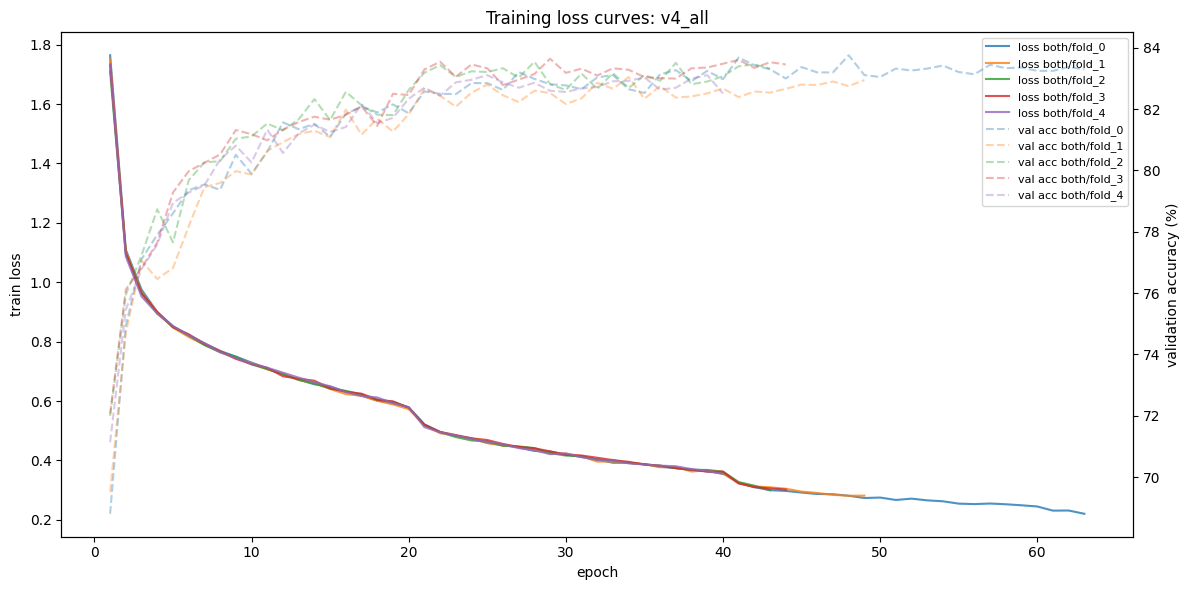

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\loss_curves_v4_all.png


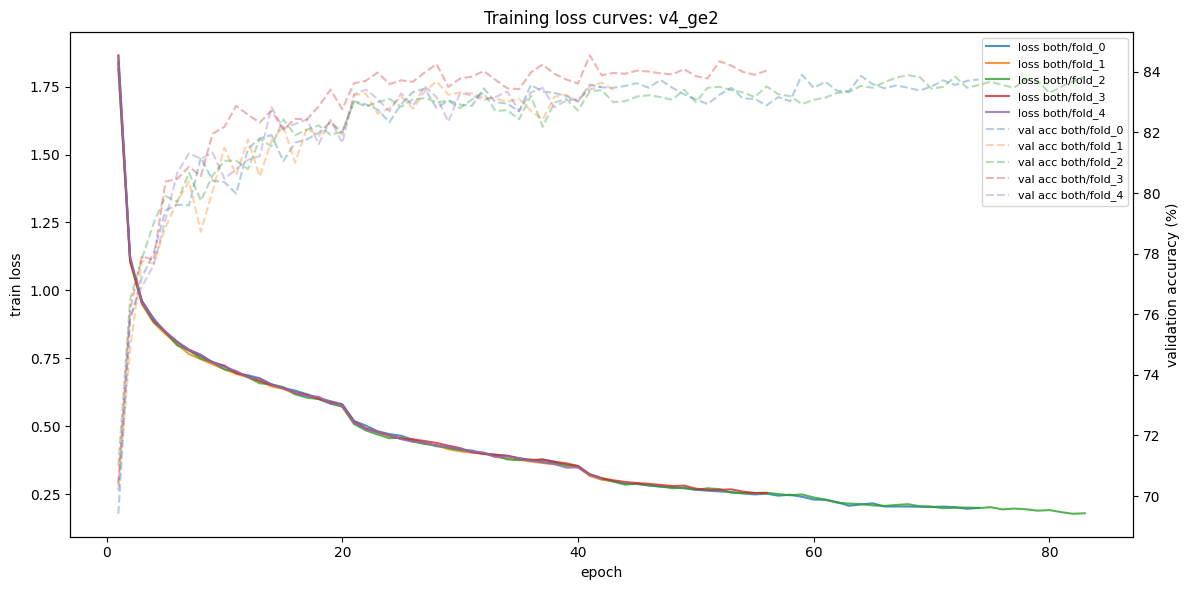

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\loss_curves_v4_ge2.png


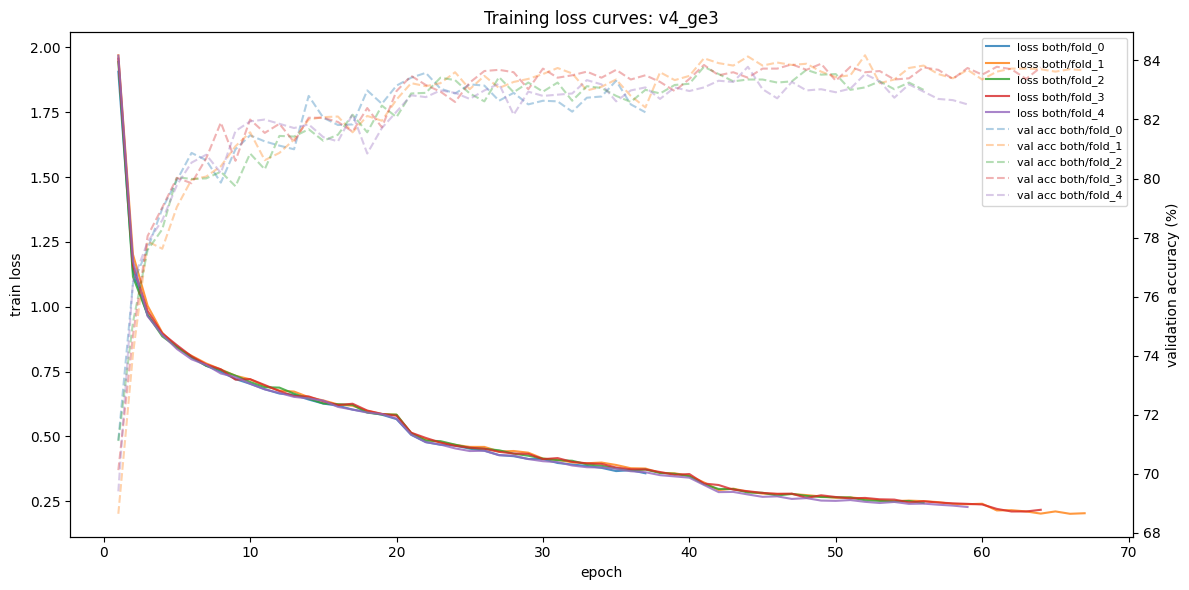

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\loss_curves_v4_ge3.png


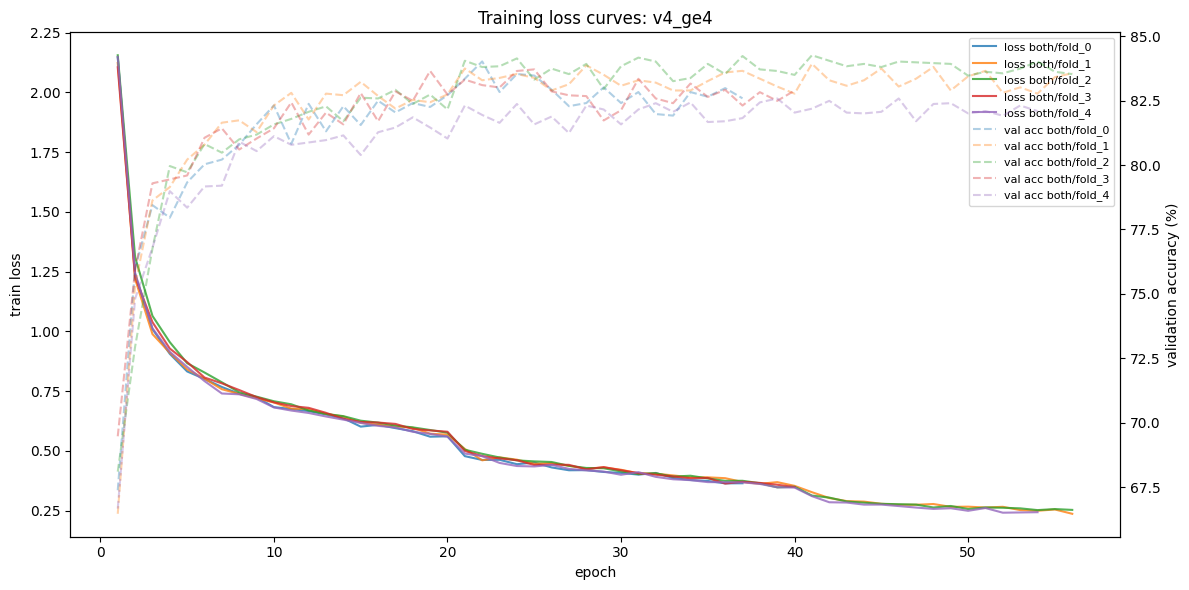

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\loss_curves_v4_ge4.png


In [30]:
def load_history(run_dir: str | Path) -> dict:
    history_path = Path(run_dir) / 'history.json'
    if not history_path.exists():
        return {}
    return json.loads(history_path.read_text(encoding='utf-8'))

def plot_loss_curves(summary_df: pd.DataFrame):
    for dataset_label, group in summary_df.groupby('dataset_label', sort=False):
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax2 = ax1.twinx()
        plotted = False
        for _, row in group.iterrows():
            hist = load_history(row['output_dir'])
            if not hist:
                continue
            loss = hist.get('train_total_loss') or hist.get('train_cls_loss')
            val_acc = hist.get('val_accuracy')
            label = f"{row['mode']}/{row['split']}"
            if loss:
                ax1.plot(range(1, len(loss) + 1), loss, alpha=0.8, label=f'loss {label}')
                plotted = True
            if val_acc:
                ax2.plot(range(1, len(val_acc) + 1), val_acc, alpha=0.35, linestyle='--', label=f'val acc {label}')
        ax1.set_title(f'Training loss curves: {dataset_label}')
        ax1.set_xlabel('epoch')
        ax1.set_ylabel('train loss')
        ax2.set_ylabel('validation accuracy (%)')
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='best')
        fig.tight_layout()
        save_path = PLOTS_DIR / f'loss_curves_{dataset_label}.png'
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        if plotted:
            plt.show()
        else:
            plt.close(fig)
        print('saved:', save_path)

plot_loss_curves(summary)

## 9. Confusion matrices

For each dataset, this cell selects the best fold by `hierarchical_accuracy` and shows its normalized confusion matrix. Each run also writes its own matrix under `output_dir/evaluation/`.

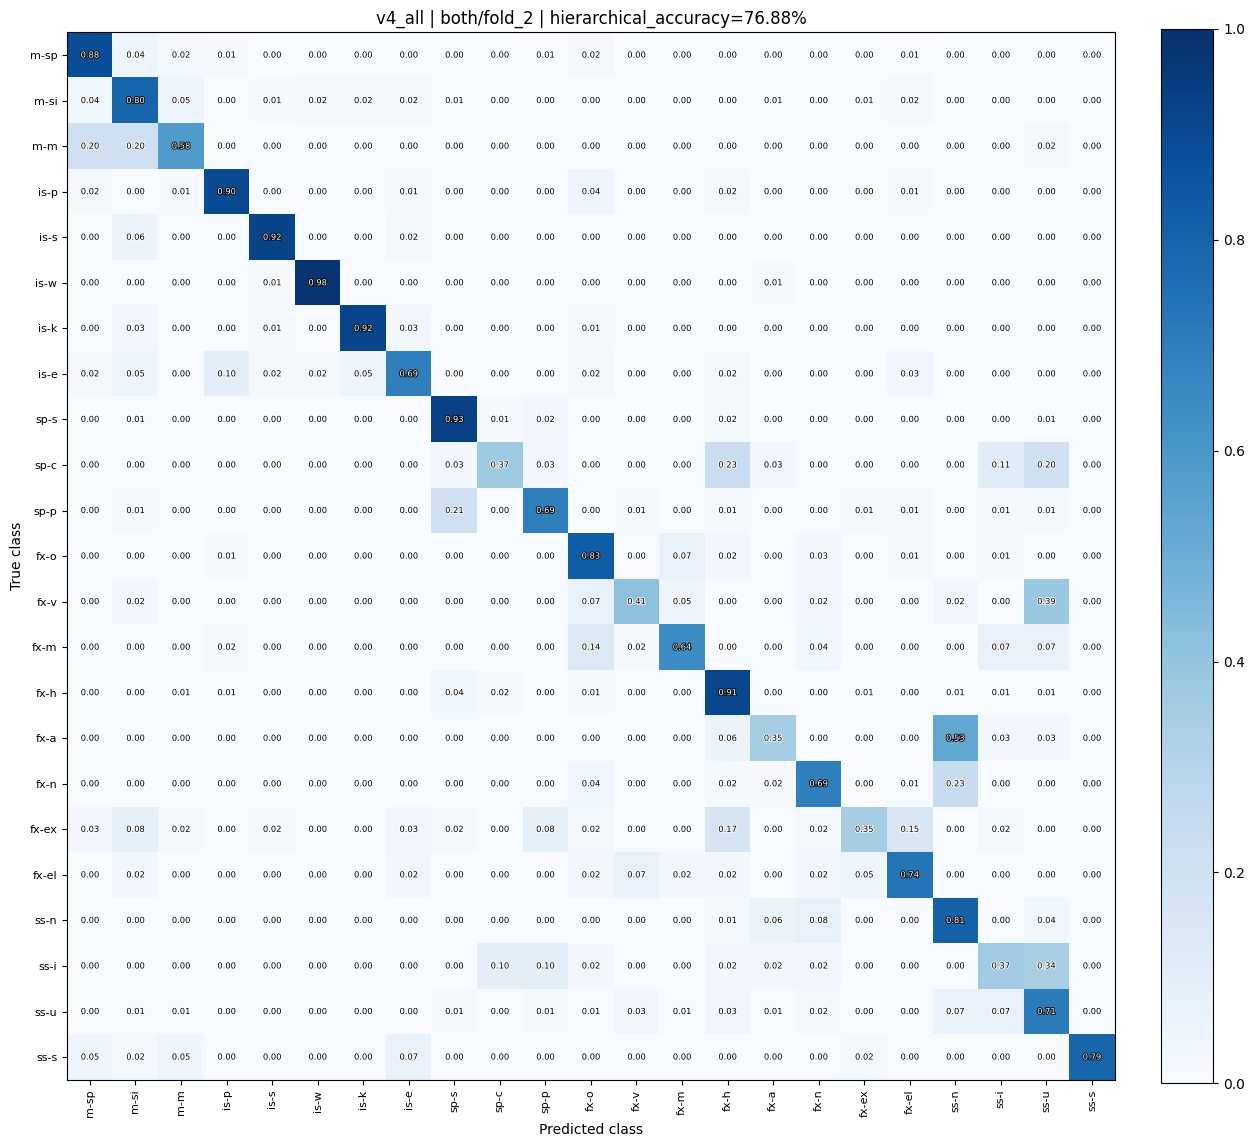

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\best_confusion_matrix_v4_all.png


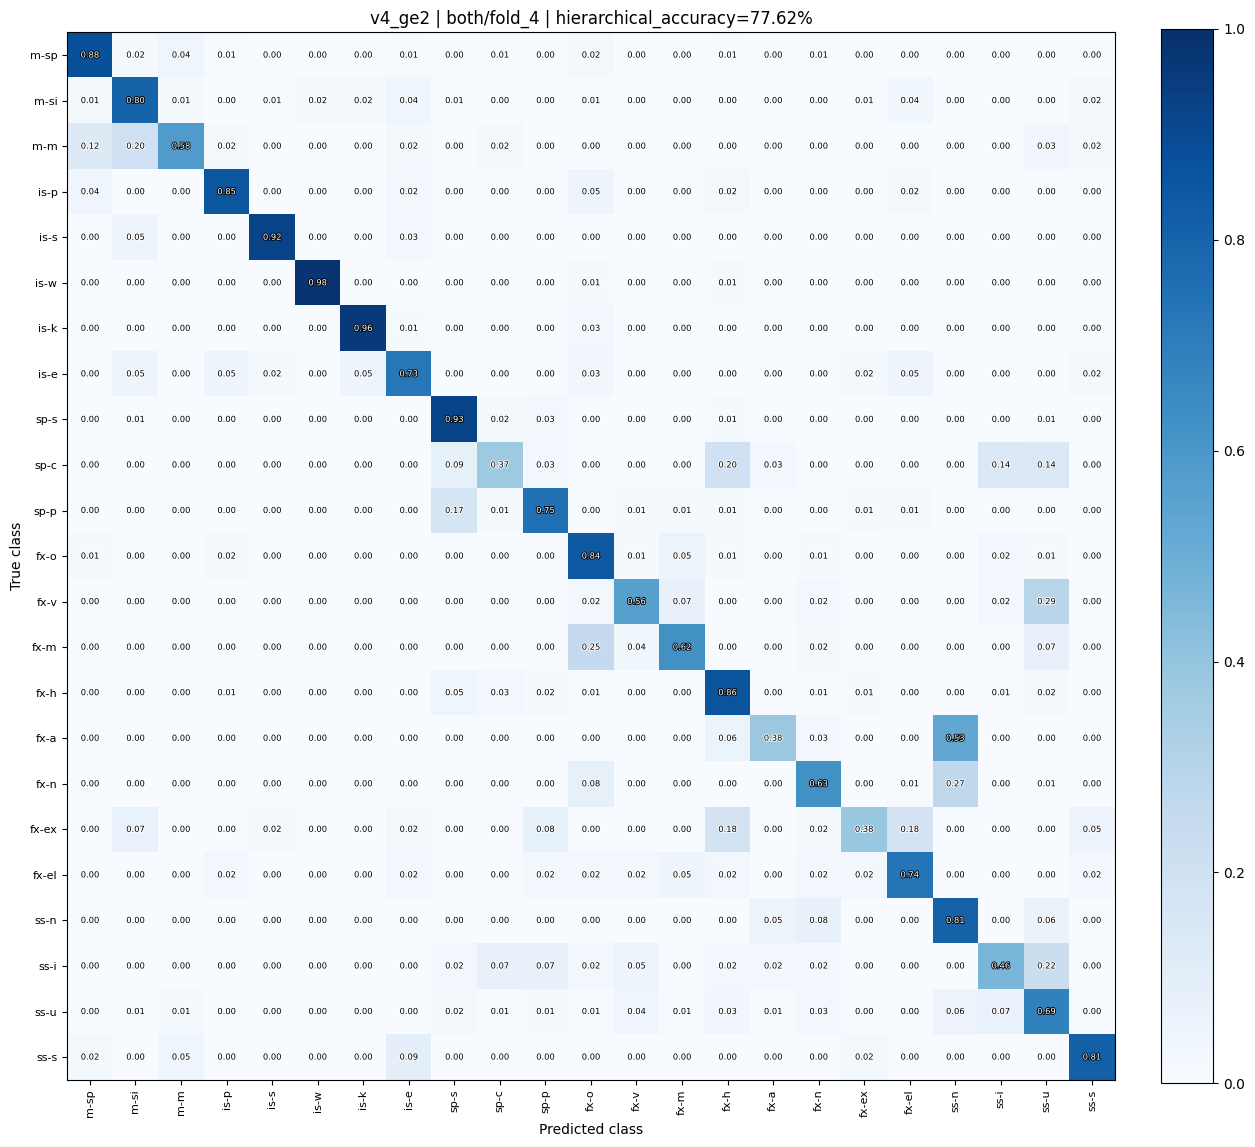

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\best_confusion_matrix_v4_ge2.png


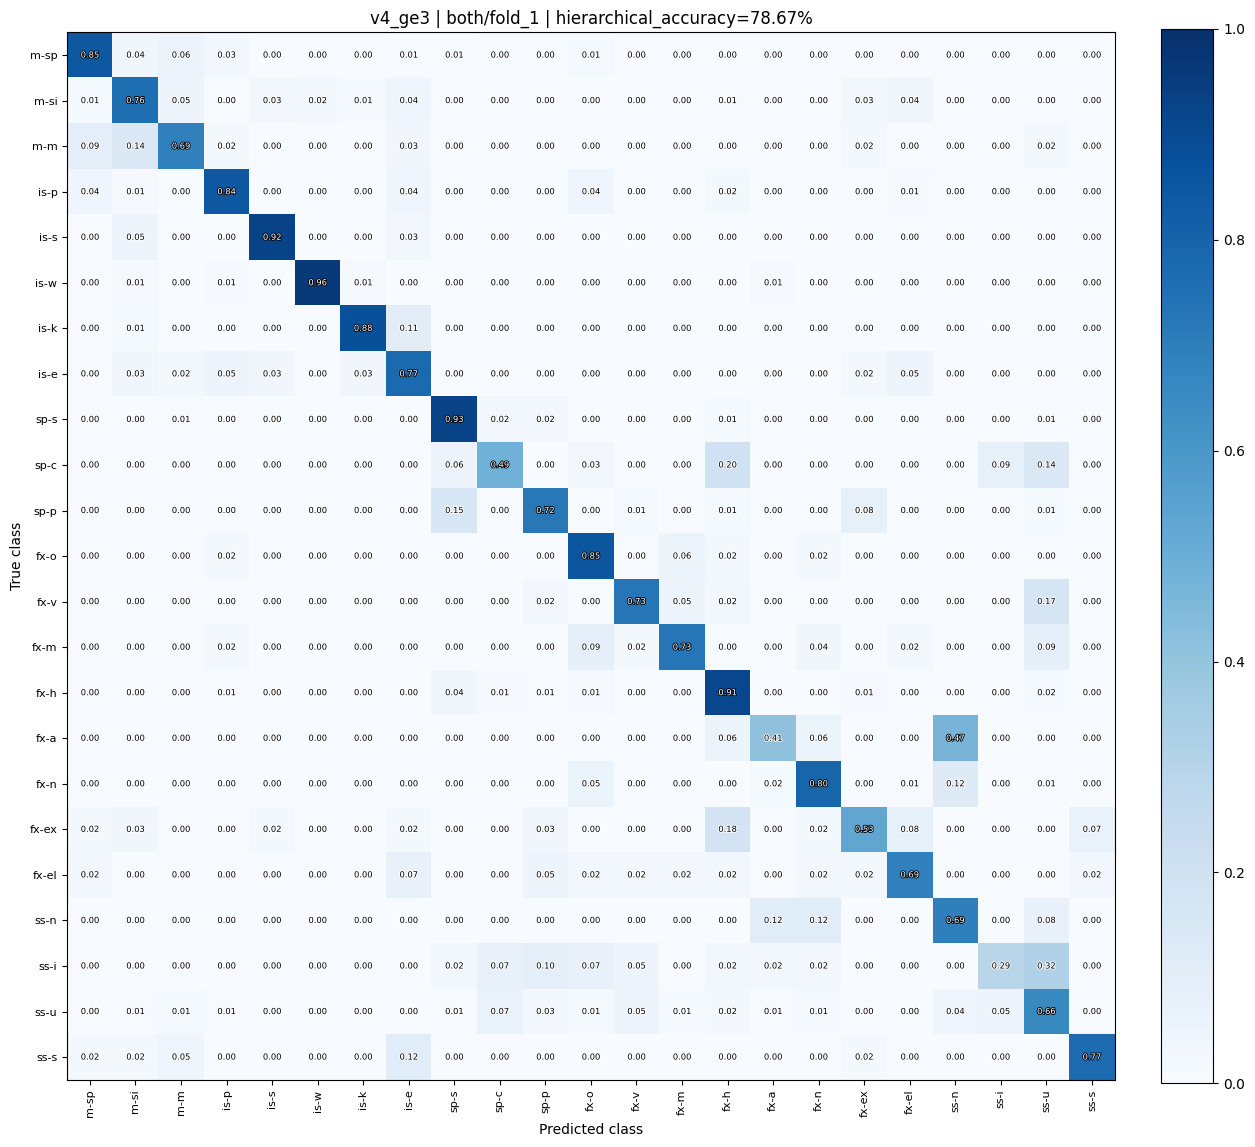

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\best_confusion_matrix_v4_ge3.png


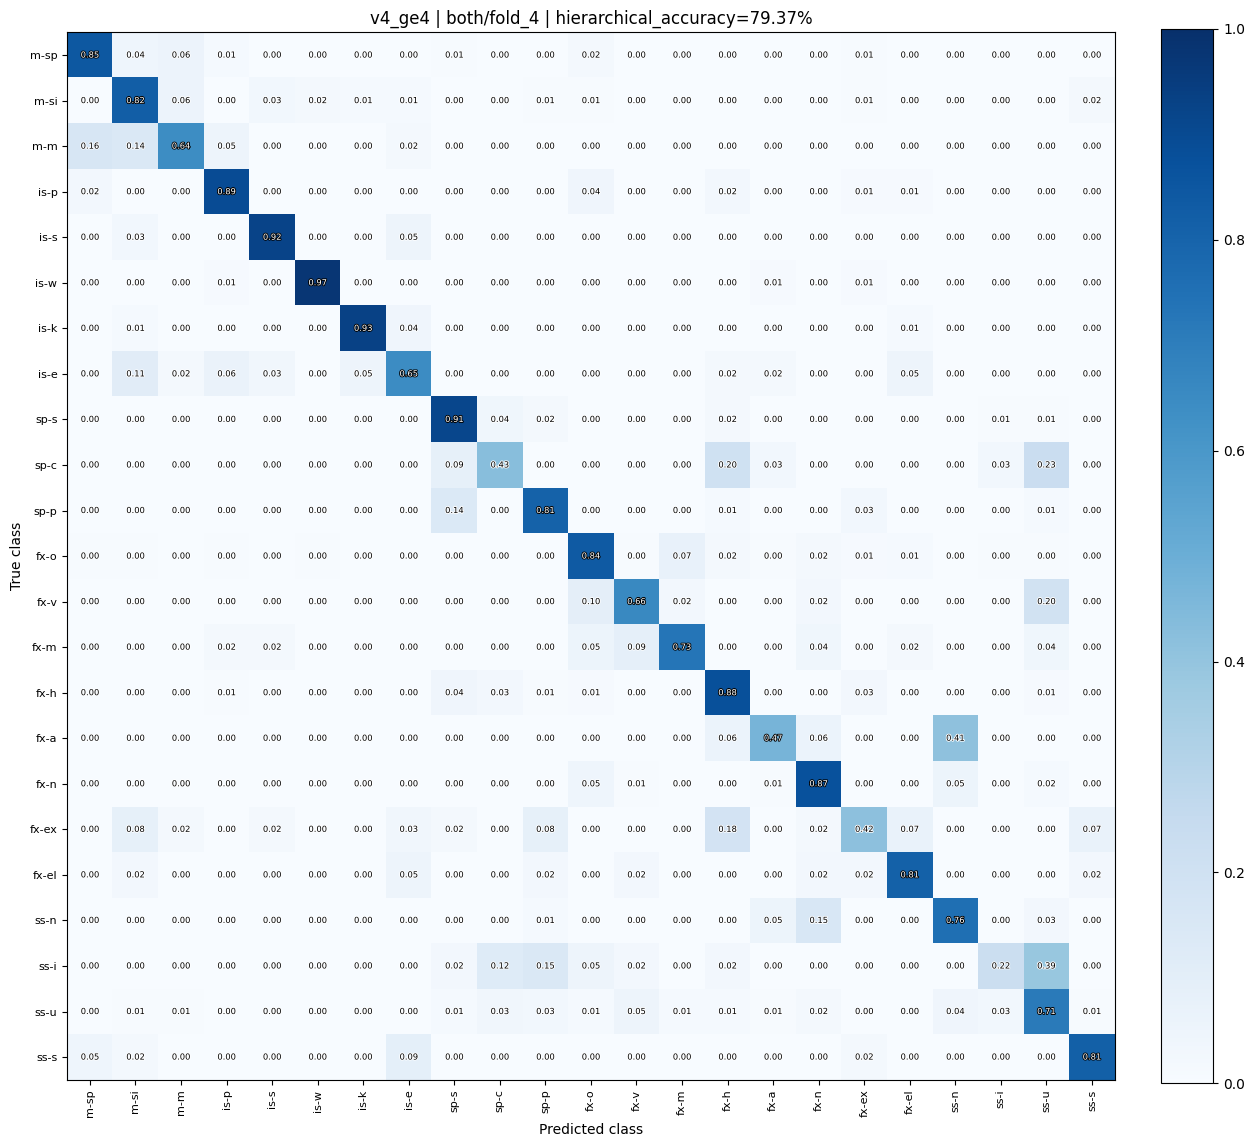

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_baseline_model\plots\best_confusion_matrix_v4_ge4.png


,dataset_label,mode,split,added_bsd35k_samples,accuracy,hierarchical_accuracy,hierarchical_f1,output_dir
2,v4_all,both,fold_2,31464,77.965328,76.875052,76.156025,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v4_ge2,both,fold_4,23851,77.919708,77.622227,76.394005,c:\Users\solok\Desktop\Dcase baseline\baseline...
11,v4_ge3,both,fold_1,15566,79.105839,78.673819,77.476651,c:\Users\solok\Desktop\Dcase baseline\baseline...
19,v4_ge4,both,fold_4,7633,80.018248,79.366424,78.283309,c:\Users\solok\Desktop\Dcase baseline\baseline...


In [31]:
def plot_confusion_from_csv(cm_path: Path, title: str, save_path: Path):
    cm_df = pd.read_csv(cm_path, index_col=0)
    labels = cm_df.index.astype(str).tolist()
    cm = cm_df.to_numpy(dtype=float)
    fig_size = max(10, len(labels) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    cbc.annotate_confusion_matrix(ax, cm, fontsize=6)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', save_path)

best_rows = []
for dataset_label, group in summary.groupby('dataset_label', sort=False):
    best_idx = pd.to_numeric(group['hierarchical_accuracy'], errors='coerce').idxmax()
    best = summary.loc[best_idx]
    best_rows.append(best)
    cm_path = Path(best['output_dir']) / 'evaluation' / 'confusion_matrix_normalized_true.csv'
    save_path = PLOTS_DIR / f'best_confusion_matrix_{dataset_label}.png'
    title = (
        f"{dataset_label} | {best['mode']}/{best['split']} | "
        f"hierarchical_accuracy={best['hierarchical_accuracy']:.2f}%"
    )
    plot_confusion_from_csv(cm_path, title, save_path)

best_folds = pd.DataFrame(best_rows)
best_folds.to_csv(OUTPUT_ROOT / 'best_folds_by_hierarchical_accuracy.csv', index=False)
display(best_folds[[
    'dataset_label', 'mode', 'split', 'added_bsd35k_samples', 'accuracy',
    'hierarchical_accuracy', 'hierarchical_f1', 'output_dir'
]])

## 10. Quick interpretation table

Use this table to compare:

- `v4_ge2/ge3/ge4` trend: how strictness trades off data amount and downstream performance.

In [32]:
ranked = fold_summary.sort_values('hierarchical_accuracy_mean', ascending=False).reset_index(drop=True)
display_cols = [
    'dataset_label', 'added_bsd35k_samples', 'fold_count',
    'accuracy_mean', 'accuracy_std',
    'hierarchical_accuracy_mean', 'hierarchical_accuracy_std',
    'hierarchical_f1_mean', 'hierarchical_f1_std',
    'macro_accuracy_mean', 'macro_accuracy_std',
]
ranked[display_cols].to_csv(OUTPUT_ROOT / 'ranked_compact_summary.csv', index=False)
display(ranked[display_cols])

,dataset_label,added_bsd35k_samples,fold_count,accuracy_mean,accuracy_std,hierarchical_accuracy_mean,hierarchical_accuracy_std,hierarchical_f1_mean,hierarchical_f1_std,macro_accuracy_mean,macro_accuracy_std
0,v4_ge4,7633,5,79.279197,0.827102,78.803487,0.634606,77.718455,0.717882,73.451313,0.650697
1,v4_ge3,15566,5,78.740876,0.468582,77.991830,0.730395,76.893118,0.720976,72.621644,0.629162
2,v4_ge2,23851,5,77.381416,0.579160,76.922331,0.694019,75.768258,0.588167,71.129826,0.781058
3,v4_all,31464,5,77.354015,0.454605,76.238702,0.435797,75.290839,0.610534,70.371117,0.657646
